# **Statistics in DataScience**

# 1. Mean(Average):

* Sum of all values ÷ number of values

* denoted by x̄ or μ

# 2. Variance:

* Average of squared differences from the mean

* denoted by σ^2

# 3. Standard Deviation (SD):

* Square root of variance

* denoted by σ

* It shows how spread out the data is.

* 1st SD: μ ± 1σ

* 2nd SD: μ ± 2σ

* 3rd SD: μ ± 3σ

# 4. Range:

* Highest value − Lowest value

# 5. Quartiles:

* Quartiles divide sorted data into 4 equal parts.

* Q1 (1st quartile) → 25% , median of the lower half of the data.
* Q2 (2nd quartile) → 50% , median of the entire dataset.
* Q3 (3rd quartile) → 75% , median of the upper half of the data.
* Interquartile Range (IQR) = Q3 − Q1

# 6. Distribution:

* How data values are spread.

* Discrete: countable and distinct values
  * Examples: number of students, dice outcome

* Continuous: measurable values
  * Examples: height, weight, time

# 7. Specific Distribution:

* Bernoulli Distribution -> Only two outcomes: 0 or 1
  * Example: pass/fail, yes/no

* Binomial Distribution -> Repeated Bernoulli trials
  * Example: number of heads in 10 coin tosses

* Normal Distribution (Gaussian / Bell-shaped):
  * Symmetrical bell curve, Most values near mean
  * follows 68–95–99.7 rule
  * mean = median = mode

# 8. Outlier:

* Value far from other data.
* outlier if x<Q1−1.5(IQR) or x>Q3+1.5(IQR)

# Practical Example Dataset:

Lets use students marks Dataset from a university for the calculation.

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

df = pd.read_csv('Students_marks.csv')
df.head(5)

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


In [19]:
total_students = len(df) # no. of students
print(f"Total number of students ={total_students}")
math_total = df['Maths'].sum() # sum of math marks
print(f"Total sum ={math_total}")
math_mean = math_total/total_students # math ko mean calculation
print(f"Mean of math marks ={math_mean}")

Total number of students =250
Total sum =13254
Mean of math marks =53.016


In [20]:
sqr = 0
for x in df['Maths']:
  sqr += (x-math_mean)**2 # sum of (x-mean)^2
variance = sqr/(total_students) # variance calculation
print(f"Variance of math marks ={variance}")

Variance of math marks =747.0157440000002


In [21]:
sd = variance**(1/2)
print(f"Standard Deviation ={sd}")

Standard Deviation =27.33158875733352


In [22]:
highest = df['Maths'].max()
lowest = df['Maths'].min()
range = highest - lowest
print(f"Range ={range}")

Range =99


In [23]:
# 1. Sort the data first!
sorted_df = df.sort_values(by=['Maths']).reset_index(drop=True)

def get_median(sorted_df, n):
  if n % 2 != 0:
      print("Odd case")
      median = sorted_df['Maths'][(n)//2] # used floor division because index should be whole numbers
  else:
      print("Even case")
      median = (sorted_df['Maths'][(n//2)-1] + sorted_df['Maths'][(n//2)])/2
  return median

median = get_median(sorted_df, total_students)
print(f"Median(Q2) ={median}")
# print(df['Maths'].median())

Even case
Median(Q2) =52.5


In [24]:
lower_half = sorted_df.iloc[:(total_students // 2)].reset_index(drop=True)
q1 = get_median(lower_half, len(lower_half))
print(f"Q1 ={q1}")

upper_half = sorted_df.iloc[(total_students // 2):].reset_index(drop=True)
q3 = get_median(upper_half, len(upper_half))
print(f"Q3 ={q3}")

Odd case
Q1 =30
Odd case
Q3 =76


In [25]:
iqr = q3 - q1
print("Internal Quartile Range:", iqr)

Internal Quartile Range: 46


Outlier Check

In [26]:
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
print(f"Upper Bound ={upper_bound}")
print(f"Lower Bound ={lower_bound}")

outlier = sorted_df[(sorted_df['Maths'] > upper_bound) | (sorted_df['Maths'] < lower_bound)]
print(f"Outlier ={outlier.values}")

Upper Bound =145.0
Lower Bound =-39.0
Outlier =[]


All values between -39 to 145
So no outlier

# Standard Deviation Intervals

In [27]:
print(f"First_SD = {int(math_mean - sd)} to {int(math_mean + sd)}")
print(f"Second_SD = {int(math_mean - 2*sd)} to {int(math_mean + 2*sd)}")
print(f"Third_SD = {int(math_mean - 3*sd)} to {int(math_mean + 3*sd)}")

First_SD = 25 to 80
Second_SD = -1 to 107
Third_SD = -28 to 135


Second and third standard deviation intervals largely contain the entire possible range of scores (1-100) suggests that the scores are well-distributed around the mean

First, I will encode the 'Gender' column to 'Gender_encoded' with 'Female' as 0 and 'Male' as 1, which is necessary for Bernoulli distribution analysis. Then, I will create a 'Passed_Subjects_Count' column by counting the number of subjects (Science, English, History, Maths) each student passed, using a passing mark of 35, which is useful for binomial distribution analysis.



In [28]:
df['Gender_encoded'] = df['Gender'].map({'Female': 0, 'Male': 1})

subject_cols = ['Science', 'English', 'History', 'Maths']
passing_mark = 35

df['Passed_Subjects_Count'] = 0

for subject in subject_cols:
    df['Passed_Subjects_Count'] += (df[subject] >= passing_mark).astype(int)

df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths,Gender_encoded,Passed_Subjects_Count
0,1,Bronnie,Female,13,C,21,81,62,49,0,3
1,2,Lemmie,Male,15,B,29,41,17,40,1,2
2,3,Danya,Female,14,C,12,87,16,96,0,2
3,4,Denna,Female,14,B,15,53,82,33,0,2
4,5,Jocelin,Male,14,A,43,6,3,21,1,1


## Visualize Discrete Distribution (Maths Marks)

I will import the necessary libraries, `seaborn` and `matplotlib.pyplot`, for data visualization. Then, I will create a bar plot to visualize the frequency of each unique 'Maths' mark, which will illustrate its discrete distribution.



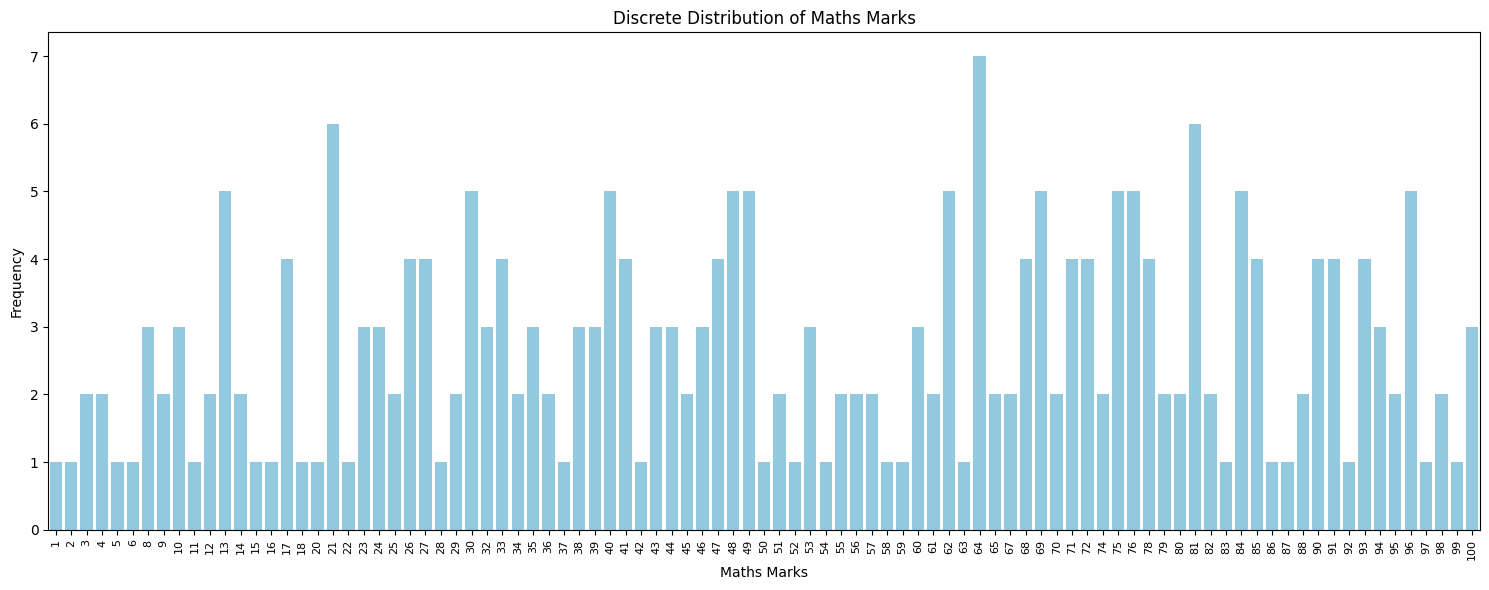

In [29]:
# Calculate the frequency of each unique Maths mark and sort them
maths_counts = df['Maths'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(15, 6))
sns.barplot(x=maths_counts.index, y=maths_counts.values, color='skyblue')
plt.title('Discrete Distribution of Maths Marks')
plt.xlabel('Maths Marks')
plt.ylabel('Frequency')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

The bar plot shows the discrete distribution of 'Maths' marks. The marks range from 1 to 100. There appears to be a relatively even spread across many marks, with some marks having higher frequencies than others.

## Visualize Continuous Distribution (Maths Marks)


To visualize the continuous distribution of 'Maths' marks, I will create a histogram using seaborn, as specified in the instructions. This will show both the frequency of marks and an estimated probability density curve.



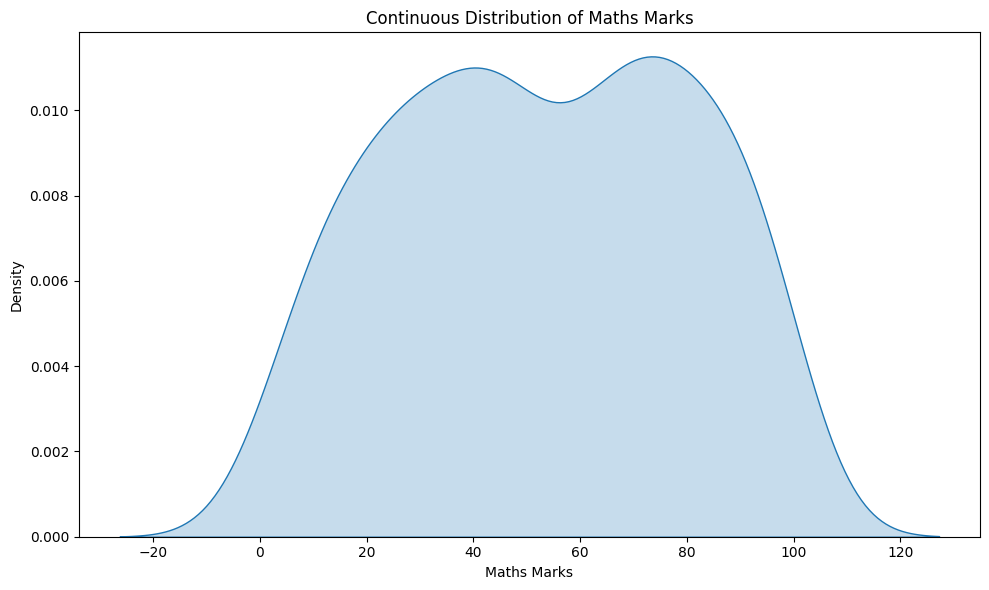

In [30]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df["Maths"],fill=True)
plt.title('Continuous Distribution of Maths Marks')
plt.xlabel('Maths Marks')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

The histogram with KDE for 'Maths' marks shows normal distribution that appears somewhat symmetrical, bell-shaped curve. The tails of the distribution on both ends suggest that there are fewer students with very low or very high marks, as expected.

## Visualize Bernoulli Distribution (Gender)


I will calculate the proportions of each gender from the 'Gender_encoded' column to prepare the data for plotting the Bernoulli distribution. Then, I will create a bar plot using seaborn to visualize these proportions.



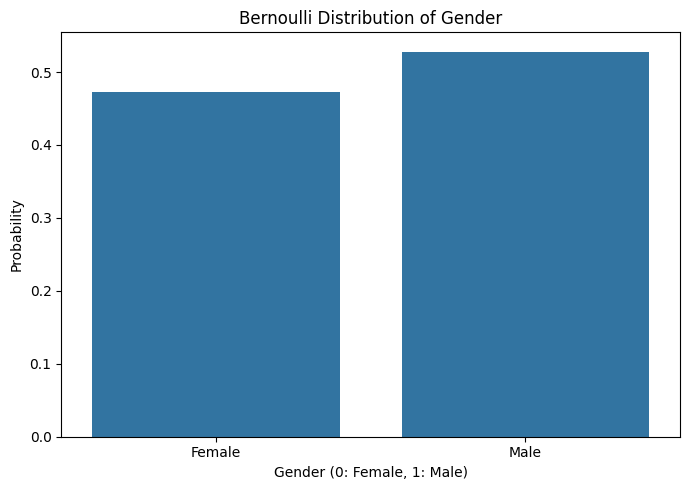

In [31]:
gender_distribution = df['Gender_encoded'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_distribution.index, y=gender_distribution.values)
plt.title('Bernoulli Distribution of Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Probability')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

The Bernoulli distribution of gender shows the probability of a student being either female (0) or male (1).

From the plot and the calculated proportions:
- The probability of a student being **Female** (encoded as 0) is approximately **0.472** or 47.2%.
- The probability of a student being **Male** (encoded as 1) is approximately **0.528** or 52.8%.

This indicates that in the given dataset, there are slightly more male students than female students.

## Visualize Binomial Distribution (Passed Subjects)


I will calculate the frequency of each unique value in the 'Passed_Subjects_Count' column and sort them by index. Then, I will create a bar plot using seaborn to visualize these frequencies, with appropriate labels and a title to represent the binomial distribution of passed subjects.


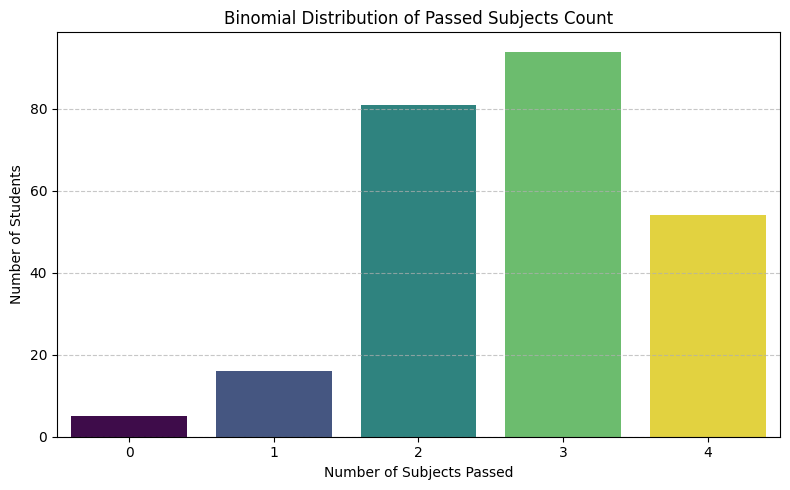

In [32]:
passed_subjects_counts = df['Passed_Subjects_Count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=passed_subjects_counts.index, y=passed_subjects_counts.values, hue=passed_subjects_counts.index, palette='viridis', legend=False)
plt.title('Binomial Distribution of Passed Subjects Count')
plt.xlabel('Number of Subjects Passed')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In this plot:
*   The distribution has a single peak at 2 subjects passed, indicating that the most common outcome is for students to pass two subjects.

## Visualize Normal Distribution (Maths Marks)


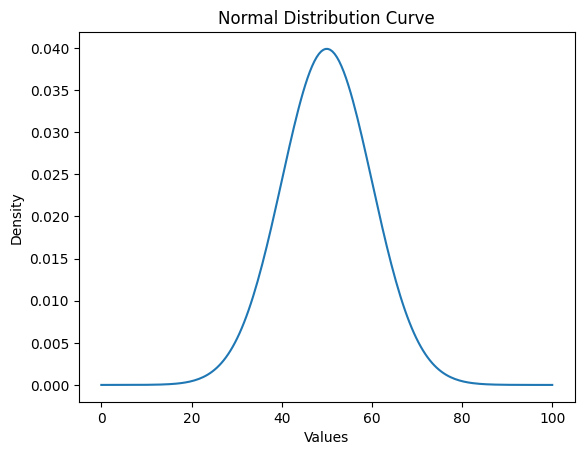

In [33]:
#creates 200 evenly spaced numbers between 0 and 100
x = np.linspace(0, 100, 200)

#calculates the height of the normal curve at each x value
y = norm.pdf(x, loc=50, scale=10)

plt.plot(x, y)
plt.title("Normal Distribution Curve")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

# 9. Central Moment

* Central moments measure how data values spread around the mean.
* μr = ∑(xi - x̄)^r / N

### 1st Central Moment

* Denoted by μ1

* μ1 = ∑(xi - x̄) / N

* Always zero (because deviations from mean sum to zero)

### 2nd Central Moment (Variance)

* Denoted by μ2
* μ2 = ∑(xi - x̄)^2 / N = σ^2
* Measures spread of data


### 3rd Central Moment

* Measures asymmetry
* Denoted by μ3
* μ3 = ∑(xi - x̄)^3 / N
* Positive → right-skewed
* Negative → left-skewed
* 0 → symmetric


# 4th Central Moment (Kurtosis base)

* Measures peakness / tail heaviness
* denoted by μ4
* μ4 = ∑(xi - x̄)^4 / N

**kurtosis:**
* Measures tailedness of a probability distribution
* Formula: β2 = μ4/μ2^2

**Excess kurtosis:**
* Measures it relative to a normal distribution
* Formula: γ2 = β2-3

# 10. Types of Kurtosis:

* Mesokurtic: normal distribution, β₂ = 3, γ2 = 0
* Leptokurtic: high peak, fat tails, β₂ > 3, γ2 > 0
* Platykurtic: flat, thin tails, β₂ < 3, γ2 < 0


In [34]:

data = df['Maths']

# Central moments
mu1 = (data - math_mean).sum()/total_students
mu2 = ((data - math_mean)**2).sum()/total_students
mu3 = ((data - math_mean)**3).sum()/total_students
mu4 = ((data - math_mean)**4).sum()/total_students

# Kurtosis
beta2 = mu4 / (mu2**2)
excess_kurtosis = beta2 - 3

print("1st central moment (μ1):", mu1)
print("2nd central moment (μ2 - Variance):", mu2)
print("3rd central moment (μ3):", mu3)
print("4th central moment (μ4):", mu4)
print("Kurtosis (β2):", beta2)
print("Excess Kurtosis (γ2):", excess_kurtosis)

# Kurtosis type
if beta2 > 3:
    print("Distribution: Leptokurtic")
elif beta2 < 3:
    print("Distribution: Platykurtic")
else:
    print("Distribution: Mesokurtic")

1st central moment (μ1): 2.842170943040401e-15
2nd central moment (μ2 - Variance): 747.0157439999999
3rd central moment (μ3): -1242.4647598079957
4th central moment (μ4): 1039431.7223283794
Kurtosis (β2): 1.8626723026923373
Excess Kurtosis (γ2): -1.1373276973076627
Distribution: Platykurtic


It shows that the math marks distribution is Platykurtic. 